In [5]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('../dataset/raw_data/Country Wise Yearly VIsitors.csv')

data_long = data.melt(id_vars=['Country'], 
                      var_name='Year', 
                      value_name='Visitors')

data_long['Year'] = data_long['Year'].astype(int)

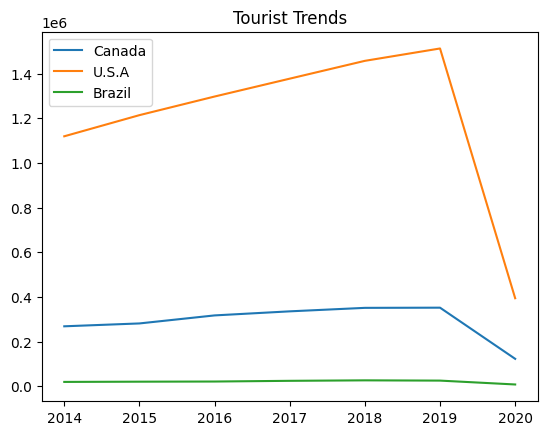

In [37]:
countries = ['Canada', 'U.S.A', 'Brazil']

for country in countries:
    temp = data_long[data_long['Country'] == country]
    plt.plot(temp['Year'], temp['Visitors'], label=country)

plt.legend()
plt.title("Tourist Trends")
plt.savefig('../outputs/graphs/TouristTrend.png')
plt.show()

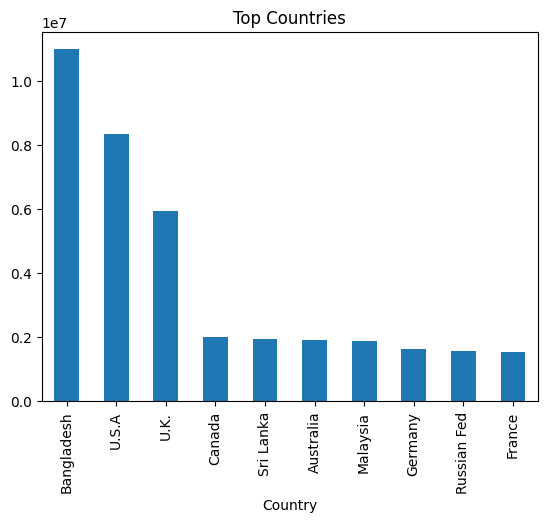

In [38]:
top_countries = data_long.groupby('Country')['Visitors'].sum().sort_values(ascending=False)

top_10 = top_countries.head(10)
top_10.plot(kind='bar')

plt.title("Top Countries")
plt.savefig('../outputs/graphs/topcountries.png')
plt.show()

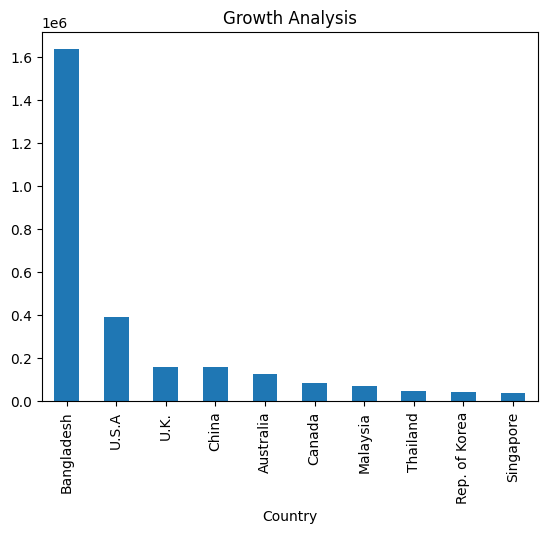

In [39]:
data_2014 = data_long[data_long['Year'] == 2014]
data_2019 = data_long[data_long['Year'] == 2019]

growth = data_2019.set_index('Country')['Visitors'] - data_2014.set_index('Country')['Visitors']

growth.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Growth Analysis")
plt.savefig('../outputs/graphs/growthanalysis.png')
plt.show()

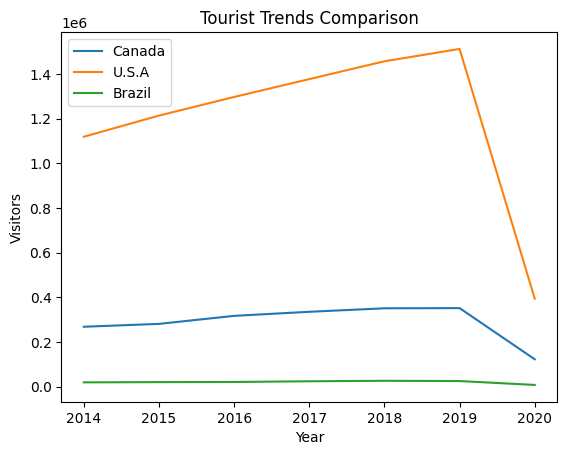

In [40]:
countries = ['Canada', 'U.S.A', 'Brazil']

plt.figure()

for country in countries:
    temp = data_long[data_long['Country'] == country]
    plt.plot(temp['Year'], temp['Visitors'], label=country)

plt.title("Tourist Trends Comparison")
plt.xlabel("Year")
plt.ylabel("Visitors")
plt.legend()
plt.savefig('../outputs/graphs/trendcomparison.png')
plt.show()

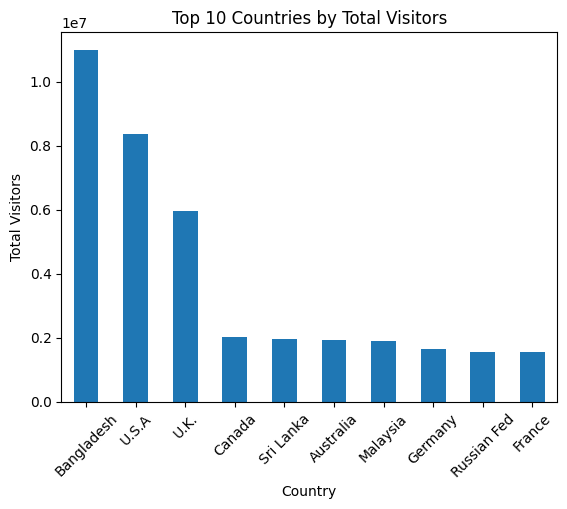

In [41]:
# total visitors per country
top_countries = data_long.groupby('Country')['Visitors'].sum().sort_values(ascending=False)

# take top 10
top_10 = top_countries.head(10)

import matplotlib.pyplot as plt

plt.figure()
top_10.plot(kind='bar')

plt.title("Top 10 Countries by Total Visitors")
plt.xlabel("Country")
plt.ylabel("Total Visitors")

plt.xticks(rotation=45)
plt.savefig('../outputs/graphs/top10bytotalvisitors.png')
plt.show()

<Figure size 640x480 with 0 Axes>

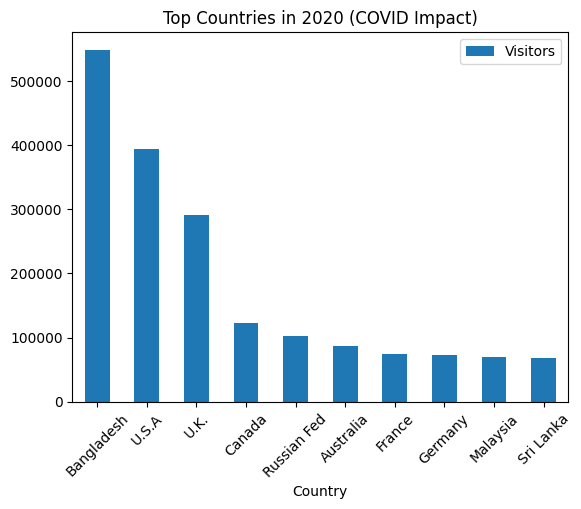

In [42]:
covid_data = data_long[data_long['Year'] == 2020]

top_covid = covid_data.sort_values(by='Visitors', ascending=False).head(10)

plt.figure()
top_covid.plot(x='Country', y='Visitors', kind='bar')

plt.title("Top Countries in 2020 (COVID Impact)")
plt.xticks(rotation=45)
plt.savefig('../outputs/graphs/covidimpact.png')
plt.show()